In [ ]:
import sys
import imfusion as imf
from imfusion import vision
import numpy as np
from matplotlib import pyplot as plt
import pathlib


QCoreApplication::applicationFilePath: Please instantiate the QApplication object first


[GL] Neither GL_NVX_gpu_memory_info nor GL_ATI_meminfo extensions available, can not query total GPU memory information.


## a. Load an image 
Loading an RGB image for relative depth estimation. Optionally also load camera intrinsics allowing to reconstruct a 3D point cloud from the depth estimate. 

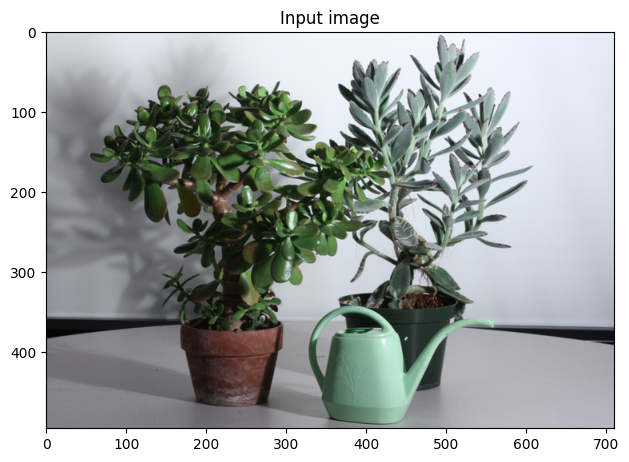

In [11]:
# Load image and attach camera calibration information.
image_path = pathlib.Path("data/stereo_left.png")
image = imf.load(str(image_path))[0]

image_calib = vision.CameraCalibrationDataComponent()
fx = 1625.408; fy = 1625.408; cx = 199.345; cy = 240.165
image_calib.intrinsic_matrix = np.array([
    [fx, 0, cx],
    [0, fy, cy],
    [0, 0, 1]
])
image_calib.distortion = np.array([0.0]*5) # k1, k2, p1, p2, k3
image_calib.image_size = np.array([image[0].width, image[0].height])
added_component = image.components.add(image_calib)

plt.imshow(image[0].numpy(), cmap='viridis')
plt.title('Input image')
plt.tight_layout()
plt.show()

## b. Reconstruction
Initialize monocular depth estimation algorithm. The algorithm estimate relative depths and also backprojects the depth to 3D to get a point cloud.  

In [ ]:
# depth estimation
params = vision.monocular_depth.DepthAnythingParameters()
reconstruction_result = vision.monocular_depth.estimate_depth(image, params)

## c. Visualize outputs


#### Visualize depth and disparity

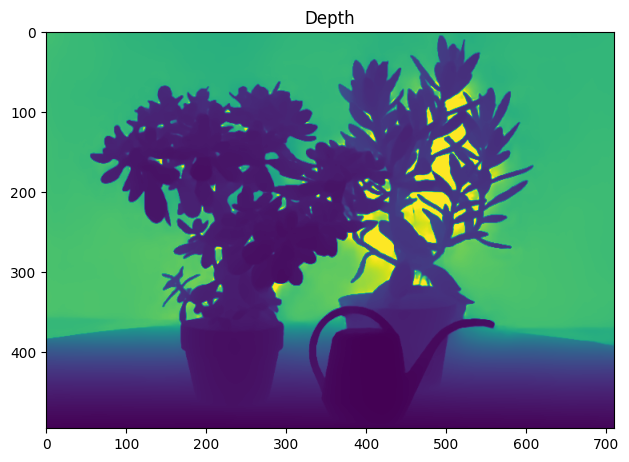

In [8]:
depth_np = reconstruction_result.depth_images.numpy() # [num_images, H, W, 1]
pointclouds = reconstruction_result.point_clouds # [num_images]

depth_vis = depth_np.squeeze((0, 3)) # [H, W]

# Show depth 
plt.imshow(depth_vis, cmap='viridis')
plt.title('Depth')
plt.tight_layout()
plt.show()

#### Visualize reconstructed point cloud

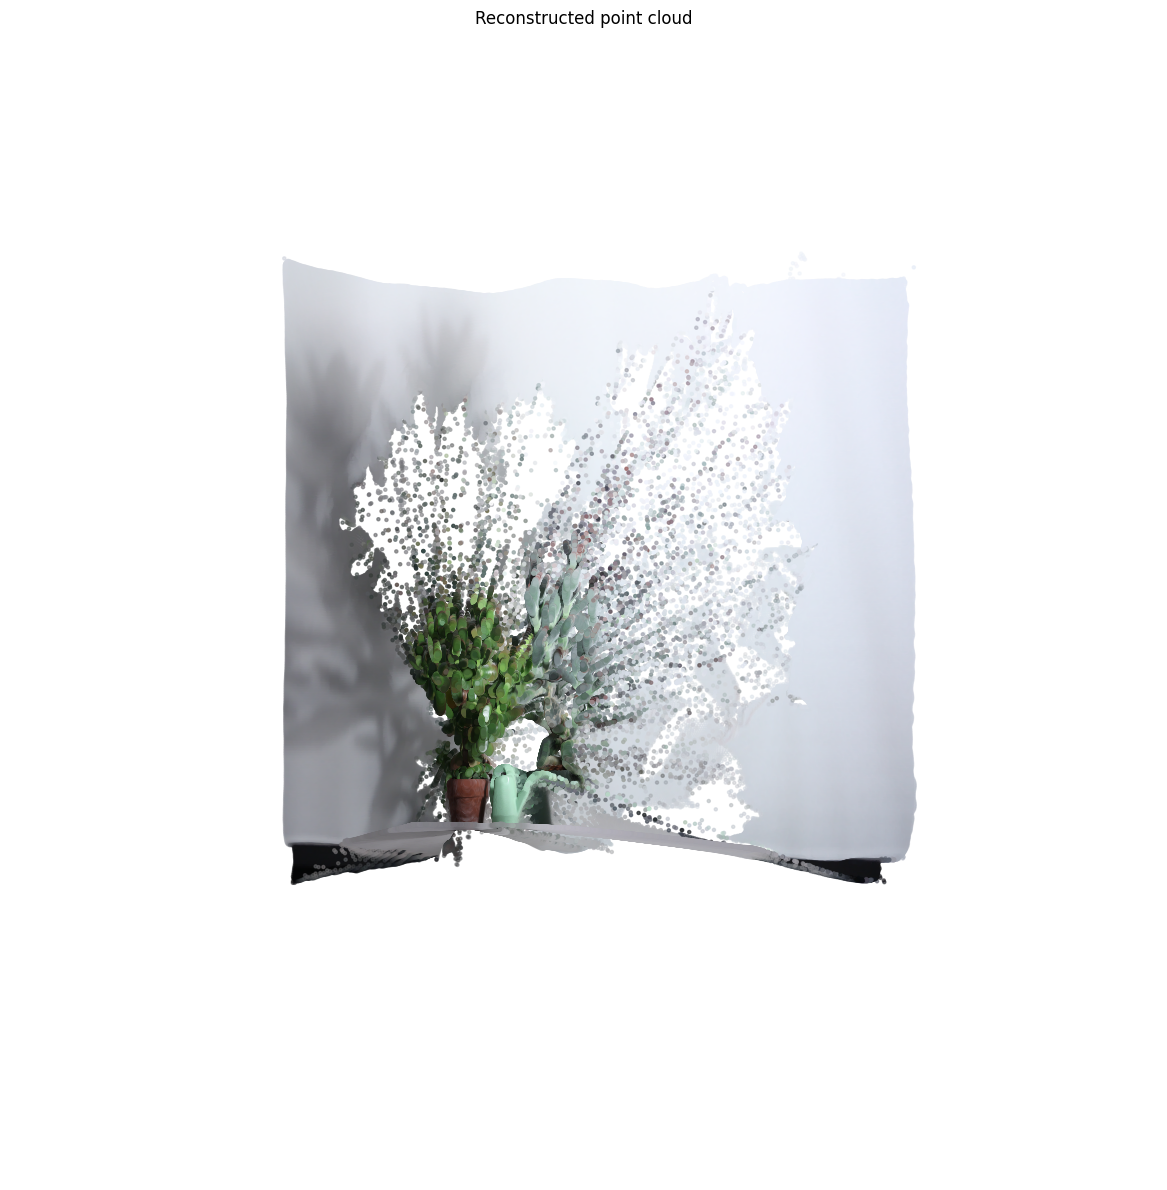

In [9]:

points_np = np.array(pointclouds[0].points) # [num_points, 3]
colors_np = np.array(pointclouds[0].colors) # [num_points, 3]
fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

x = points_np[:, 0]
y = points_np[:, 1]
z = points_np[:, 2]

# Plot with actual RGB colors
ax.scatter(x, y, z, c=colors_np, s=5)

ax.set_title('Reconstructed point cloud')
ax.view_init(elev=-80, azim=-90)
plt.axis('off')
plt.tight_layout()
plt.show()